In [2]:
import pandas as pd

df = pd.read_csv("retail_sales.csv")

df.head()

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100


In [3]:
print("Rows and Columns:")
print(df.shape)

print("\nColumn Names:")
print(df.columns)

print("\nData Information:")
df.info()

Rows and Columns:
(1000, 9)

Column Names:
Index(['Transaction ID', 'Date', 'Customer ID', 'Gender', 'Age',
       'Product Category', 'Quantity', 'Price per Unit', 'Total Amount'],
      dtype='object')

Data Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Transaction ID    1000 non-null   int64 
 1   Date              1000 non-null   object
 2   Customer ID       1000 non-null   object
 3   Gender            1000 non-null   object
 4   Age               1000 non-null   int64 
 5   Product Category  1000 non-null   object
 6   Quantity          1000 non-null   int64 
 7   Price per Unit    1000 non-null   int64 
 8   Total Amount      1000 non-null   int64 
dtypes: int64(5), object(4)
memory usage: 70.4+ KB


In [4]:
df.isnull().sum()

Transaction ID      0
Date                0
Customer ID         0
Gender              0
Age                 0
Product Category    0
Quantity            0
Price per Unit      0
Total Amount        0
dtype: int64

In [5]:
df.duplicated().sum()

0

In [6]:
df.dtypes

Transaction ID       int64
Date                object
Customer ID         object
Gender              object
Age                  int64
Product Category    object
Quantity             int64
Price per Unit       int64
Total Amount         int64
dtype: object

In [7]:
df['Date'] = pd.to_datetime(df['Date'])

df.dtypes

Transaction ID               int64
Date                datetime64[ns]
Customer ID                 object
Gender                      object
Age                          int64
Product Category            object
Quantity                     int64
Price per Unit               int64
Total Amount                 int64
dtype: object

In [8]:
df.describe()

,Transaction ID,Date,Age,Quantity,Price per Unit,Total Amount
count,1000.000000,1000,1000.00000,1000.000000,1000.000000,1000.000000
mean,500.500000,2023-07-03 00:25:55.200000256,41.39200,2.514000,179.890000,456.000000
min,1.000000,2023-01-01 00:00:00,18.00000,1.000000,25.000000,25.000000
25%,250.750000,2023-04-08 00:00:00,29.00000,1.000000,30.000000,60.000000
50%,500.500000,2023-06-29 12:00:00,42.00000,3.000000,50.000000,135.000000
75%,750.250000,2023-10-04 00:00:00,53.00000,4.000000,300.000000,900.000000
max,1000.000000,2024-01-01 00:00:00,64.00000,4.000000,500.000000,2000.000000
std,288.819436,NaN,13.68143,1.132734,189.681356,559.997632


In [3]:
numeric_df = df.select_dtypes(include='number')

summary = pd.DataFrame({
    'Mean': numeric_df.mean(),
    'Median': numeric_df.median(),
    'Mode': numeric_df.mode().iloc[0],
    'Standard Deviation': numeric_df.std()
})

summary

,Mean,Median,Mode,Standard Deviation
Transaction ID,500.500,500.5,1.0,288.819436
Age,41.392,42.0,43.0,13.681430
Quantity,2.514,3.0,4.0,1.132734
Price per Unit,179.890,50.0,50.0,189.681356
Total Amount,456.000,135.0,50.0,559.997632


In [9]:
df['Product Category'].value_counts()

Product Category
Clothing       351
Electronics    342
Beauty         307
Name: count, dtype: int64

In [10]:
df['Gender'].value_counts()

Gender
Female    510
Male      490
Name: count, dtype: int64

In [11]:
df.groupby('Product Category')['Total Amount'].sum()

Product Category
Beauty         143515
Clothing       155580
Electronics    156905
Name: Total Amount, dtype: int64

In [7]:
df['Date'] = pd.to_datetime(df['Date'])

df['Month'] = df['Date'].dt.month

monthly_sales = df.groupby('Month')['Total Amount'].sum()

monthly_sales

Month
1     36980
2     44060
3     28990
4     33870
5     53150
6     36715
7     35465
8     36960
9     23620
10    46580
11    34920
12    44690
Name: Total Amount, dtype: int64

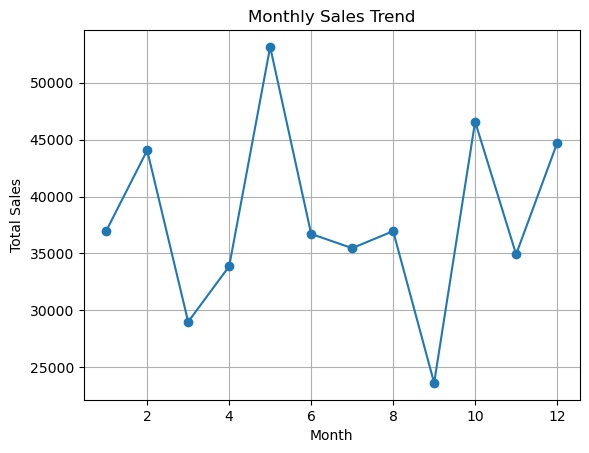

In [9]:
import matplotlib.pyplot as plt

monthly_sales.plot(kind='line', marker='o')

plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Total Sales')
plt.grid(True)

plt.show()

### Observation




The monthly sales trend shows that sales vary across different months.
May recorded the highest monthly sales, while September recorded the lowest sales.
This shows that sales performance changes from month to month.

In [11]:
df['Quarter'] = df['Date'].dt.to_period('Q')

quarterly_sales = df.groupby('Quarter')['Total Amount'].sum()

quarterly_sales

Quarter
2023Q1    108500
2023Q2    123735
2023Q3     96045
2023Q4    126190
2024Q1      1530
Freq: Q-DEC, Name: Total Amount, dtype: int64

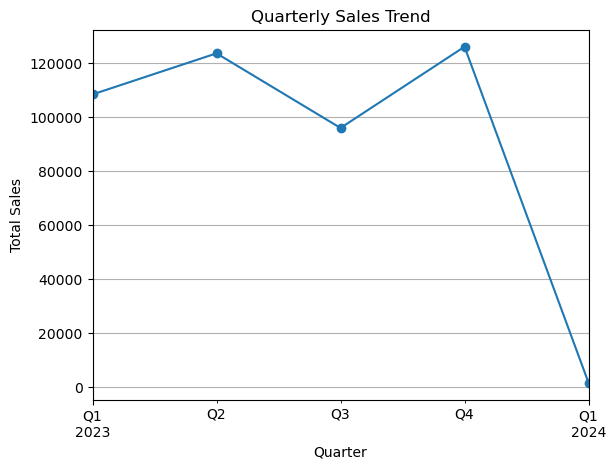

In [12]:
quarterly_sales.plot(kind='line', marker='o')

plt.title('Quarterly Sales Trend')
plt.xlabel('Quarter')
plt.ylabel('Total Sales')
plt.grid(True)

plt.show()

### Observation




The monthly sales trend shows that sales vary across different months.
May recorded the highest monthly sales, while September recorded the lowest sales.
This shows that sales performance changes from month to month.

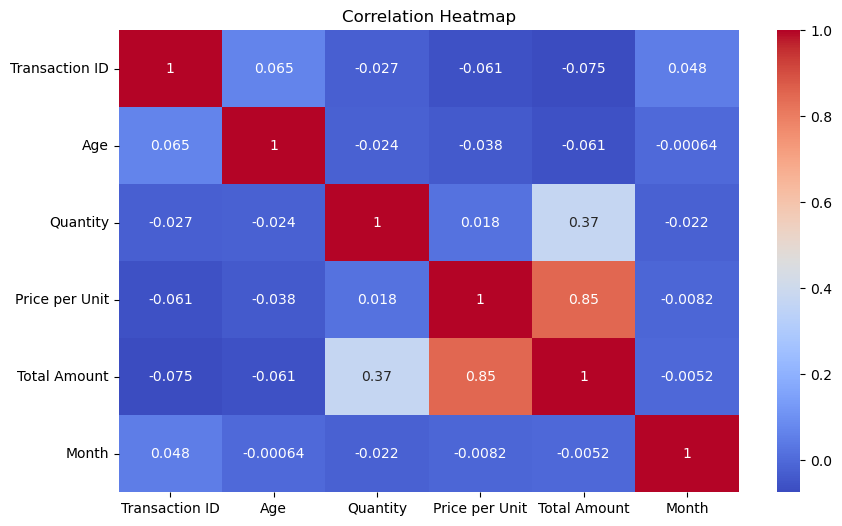

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt

correlation = df.corr(numeric_only=True)

plt.figure(figsize=(10, 6))
sns.heatmap(correlation, annot=True, cmap='coolwarm')

plt.title('Correlation Heatmap')
plt.show()

### Observation



Quarterly sales were highest in Q4 2023 with total sales of ₹126,190. 
Q3 2023 recorded the lowest sales among the full quarters with ₹96,045.
The Q1 2024 value is low because the dataset contains only limited data for January 2024.

In [15]:
category_sales = df.groupby('Product Category')['Total Amount'].sum()
category_sales

Product Category
Beauty         143515
Clothing       155580
Electronics    156905
Name: Total Amount, dtype: int64

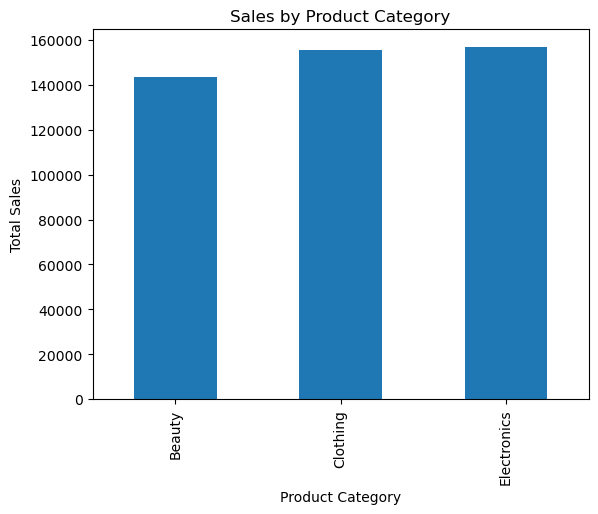

In [16]:
category_sales.plot(kind='bar')

plt.title('Sales by Product Category')
plt.xlabel('Product Category')
plt.ylabel('Total Sales')

plt.show()

### Observation



Electronics generated the highest total sales of ₹156,905, followed by Clothing with ₹155,580.
Beauty generated the lowest total sales of ₹143,515.
Overall, Electronics and Clothing contributed slightly higher sales than Beauty.

In [16]:
bins = [17, 25, 35, 45, 55, 64]
labels = ['18-25', '26-35', '36-45', '46-55', '56-64']

df['Age Group'] = pd.cut(df['Age'], bins=bins, labels=labels)

age_sales = df.groupby('Age Group', observed=True)['Total Amount'].sum()

age_sales

Age Group
18-25     84550
26-35     98480
36-45     91870
46-55    100690
56-64     80410
Name: Total Amount, dtype: int64

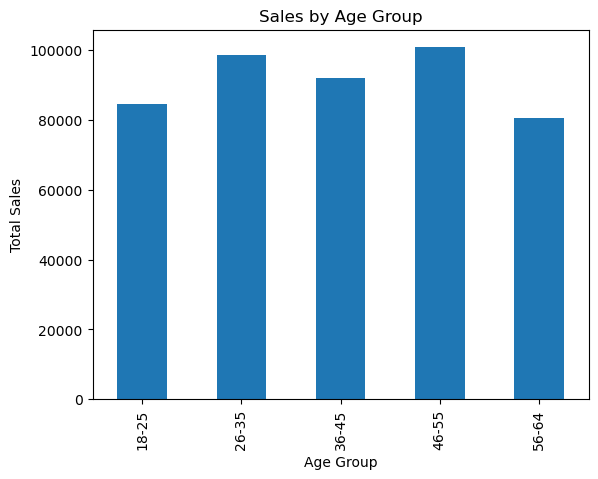

In [17]:
age_sales.plot(kind='bar')

plt.title('Sales by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Total Sales')
plt.show()

### Observation



The 46-55 age group generated the highest sales of ₹100,690.
The 56-64 age group generated the lowest sales of ₹80,410.
This shows that sales contribution varies across different customer age groups.

In [18]:
gender_sales = df.groupby('Gender')['Total Amount'].sum()

gender_sales

Gender
Female    232840
Male      223160
Name: Total Amount, dtype: int64

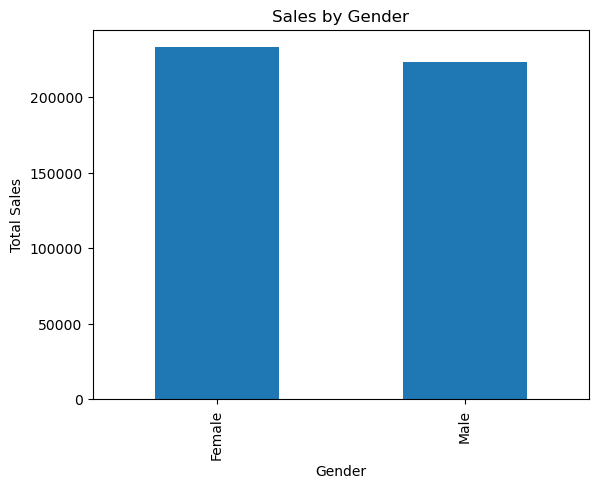

In [19]:
gender_sales.plot(kind='bar')

plt.title('Sales by Gender')
plt.xlabel('Gender')
plt.ylabel('Total Sales')
plt.show()

### Observation



Female customers generated total sales of ₹232,840, while male customers generated ₹223,160.
The sales contribution from both genders is relatively balanced, with female customers contributing slightly higher sales.

In [20]:
quantity_sales = df.groupby('Quantity')['Total Amount'].sum()

quantity_sales

Quantity
1     44805
2     81050
3    144285
4    185860
Name: Total Amount, dtype: int64

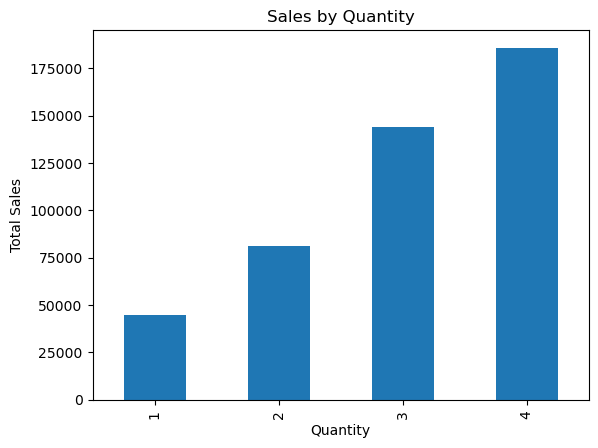

In [21]:
quantity_sales.plot(kind='bar')

plt.title('Sales by Quantity')
plt.xlabel('Quantity')
plt.ylabel('Total Sales')
plt.show()

### Observation



Transactions with a quantity of 4 generated the highest total sales of ₹185,860.
Transactions with a quantity of 1 generated the lowest total sales of ₹44,805.
This indicates that higher quantities generally contribute to higher total sales.

In [17]:
top_sales = df.nlargest(10, 'Total Amount')

top_sales[['Transaction ID', 'Customer ID', 'Product Category',
           'Quantity', 'Total Amount']]

,Transaction ID,Customer ID,Product Category,Quantity,Total Amount
14,15,CUST015,Electronics,4,2000
64,65,CUST065,Electronics,4,2000
71,72,CUST072,Electronics,4,2000
73,74,CUST074,Beauty,4,2000
88,89,CUST089,Electronics,4,2000
92,93,CUST093,Beauty,4,2000
108,109,CUST109,Electronics,4,2000
117,118,CUST118,Electronics,4,2000
123,124,CUST124,Clothing,4,2000
138,139,CUST139,Beauty,4,2000


### Note



The dataset does not contain a Product Name column.
Therefore, exact top 10 best-selling products cannot be identified.
As an alternative analysis, the top 10 highest-value transactions are shown.

## Key Insights

- Electronics generated the highest total sales of ₹156,905.
- Clothing generated total sales of ₹155,580.
- Beauty generated total sales of ₹143,515.
- Female customers generated ₹232,840 in total sales, while male customers generated ₹223,160.
- The 46-55 age group generated the highest sales of ₹100,690.
- May recorded the highest monthly sales of ₹53,150.
- Quantity 4 generated the highest total sales of ₹185,860.
- The highest transaction amount in the dataset was ₹2,000.

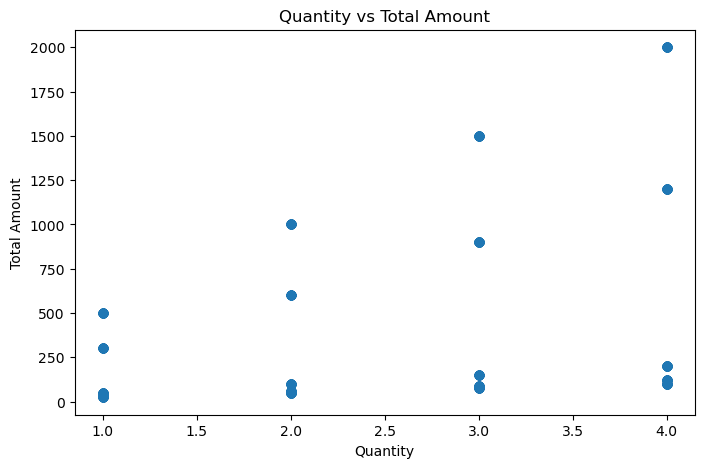

In [18]:
plt.figure(figsize=(8,5))

plt.scatter(df['Quantity'], df['Total Amount'])

plt.title('Quantity vs Total Amount')
plt.xlabel('Quantity')
plt.ylabel('Total Amount')

plt.show()

### Observation



The scatter plot shows that transactions with higher quantities generally tend to have higher total amounts.
This indicates a positive relationship between quantity purchased and transaction value.

## Conclusion



The Retail Sales dataset was analyzed using Python and Pandas. 
The analysis included data cleaning, descriptive statistics, category-wise sales, monthly sales, gender-wise sales, age-group analysis, and quantity-wise sales.

The dataset contained 1,000 transactions with no missing or duplicate records. 
Electronics generated the highest total sales among the product categories. 
The 46-55 age group generated the highest sales, and May recorded the highest monthly sales.

Overall, the analysis helped identify important sales patterns and customer trends that can be useful for business decision-making.

### Business Recommendations



1. Focus more on Electronics and Clothing categories because they generated higher total sales.
2. Plan promotional campaigns during months with lower sales to improve overall revenue.
3. Target the 46-55 age group with suitable offers and marketing campaigns because this group generated the highest sales.